In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

import utils.v3.firm as Firm
import utils.v3.household as Household
import utils.v3.information as Information
import utils.v3.countries as Countries

## Load data

In [2]:
df = pd.read_csv("Data/Clean/Final.csv")
df

,iso3_o,iso3_d,year,distance_km,shared_border,common_legal_origin,language_proximity,language_spoken_share,common_official_language,Index Year_d,...,TFP_o,year_o,Real GDP_d,Capital Stock_d,Worker Population_d,Total Population_d,Labour Share_d,Depreciation Rate_d,TFP_d,year_d
0,ABW,ABW,1997,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1997.0,3531.740967,9336.132812,0.037406,0.081106,0.634907,0.035945,NaN,1997.0
1,ABW,ABW,1998,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1998.0,3767.188477,10134.475586,0.038947,0.083777,0.638232,0.035930,NaN,1998.0
2,ABW,ABW,1999,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1999.0,3810.679932,10909.001953,0.040518,0.086472,0.655211,0.035447,NaN,1999.0
3,ABW,ABW,2000,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,2000.0,3982.696289,11437.366211,0.041918,0.088761,0.645106,0.034938,NaN,2000.0
4,ABW,ABW,2001,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,2001.0,3918.971436,11965.093750,0.042579,0.090305,0.645106,0.034852,NaN,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476220,ZWE,ZWE,2017,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.132940,2017.0,45207.550781,102027.710938,5.204640,14.812482,0.533381,0.057745,1.132940,2017.0
1476221,ZWE,ZWE,2018,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.153515,2018.0,47332.304688,105167.187500,5.235959,15.034452,0.533381,0.059023,1.153515,2018.0
1476222,ZWE,ZWE,2019,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.057740,2019.0,44445.031250,107682.148438,5.272343,15.271368,0.533381,0.059923,1.057740,2019.0
1476223,ZWE,ZWE,2020,42.0,0.0,1.0,NaN,NaN,NaN,NaN,...,0.973187,2020.0,40970.785156,109248.289062,5.206007,15.526888,0.533381,0.060208,0.973187,2020.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476225 entries, 0 to 1476224
Data columns (total 36 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   iso3_o                    1476225 non-null  object 
 1   iso3_d                    1476225 non-null  object 
 2   year                      1476225 non-null  int64  
 3   distance_km               1359650 non-null  float64
 4   shared_border             1359650 non-null  float64
 5   common_legal_origin       1352425 non-null  float64
 6   language_proximity        936050 non-null   float64
 7   language_spoken_share     936050 non-null   float64
 8   common_official_language  936050 non-null   float64
 9   Index Year_d              255150 non-null   float64
 10  Overall Score_d           242757 non-null   float64
 11  Investment Freedom_d      244701 non-null   float64
 12  Financial Freedom_d       244944 non-null   float64
 13  Tax Burden_d              2

In [4]:
# Rename the columns to macroeconomic variables
COLUMN_MAP = {
    # ── Identifiers ───────────────────────────────────────────
    "iso3_o"                   : "iso3_i",        # source country ISO3
    "iso3_d"                   : "iso3_j",        # destination country ISO3
    "year"                     : "year",

    # ── Gravity / bilateral variables ─────────────────────────
    "distance_km"              : "dist",          # log this before use
    "shared_border"            : "border",
    "common_legal_origin"      : "legal_i",
    "language_proximity"       : "lang",
    "language_spoken_share"    : "lang_share",
    "common_official_language" : "lang_official",

    # ── Legal / institutional (destination) ───────────────────
    "Overall Score_o"          : "legal_i",       # primary legal index
    "Investment Freedom_o"     : "inv_freedom_i",
    "Financial Freedom_o"      : "fin_freedom_i",
    "Tax Burden_o"             : "tax_i",

    # ── CPIS bilateral flows ───────────────────────────────────
    "cpis"                     : "cpis",          # log this before use
    "cpis_t-1"                 : "cpis_lag1",     # log this before use

    # ── MSCI returns ──────────────────────────────────────────
    "MSCI_Return_o"            : "r_i",
    "MSCI_Return_d"            : "r_j",

    # ── Macro — source country (i) ────────────────────────────
    "Real GDP_o"               : "Y_i",
    "Capital Stock_o"          : "K_i",
    "Worker Population_o"      : "L_i",
    "Total Population_o"       : "pop_i",
    "Labour Share_o"           : "lab_sh_i",      # alpha_i = 1 - lab_sh_i
    "Depreciation Rate_o"      : "delta_i",
    "TFP_o"                    : "A_i",

    # ── Macro — destination country (j) ───────────────────────
    "Real GDP_d"               : "Y_j",
    "Capital Stock_d"          : "K_j",
    "Worker Population_d"      : "L_j",
    "Total Population_d"       : "pop_j",
    "Labour Share_d"           : "lab_sh_j",      # alpha_j = 1 - lab_sh_j
    "Depreciation Rate_d"      : "delta_j",
    "TFP_d"                    : "A_j",
}

df = df.rename(columns=COLUMN_MAP)
df

,iso3_i,iso3_j,year,dist,border,legal_i,lang,lang_share,lang_official,Index Year_d,...,A_i,year_o,Y_j,K_j,L_j,pop_j,lab_sh_j,delta_j,A_j,year_d
0,ABW,ABW,1997,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1997.0,3531.740967,9336.132812,0.037406,0.081106,0.634907,0.035945,NaN,1997.0
1,ABW,ABW,1998,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1998.0,3767.188477,10134.475586,0.038947,0.083777,0.638232,0.035930,NaN,1998.0
2,ABW,ABW,1999,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,1999.0,3810.679932,10909.001953,0.040518,0.086472,0.655211,0.035447,NaN,1999.0
3,ABW,ABW,2000,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,2000.0,3982.696289,11437.366211,0.041918,0.088761,0.645106,0.034938,NaN,2000.0
4,ABW,ABW,2001,32.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,2001.0,3918.971436,11965.093750,0.042579,0.090305,0.645106,0.034852,NaN,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476220,ZWE,ZWE,2017,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.132940,2017.0,45207.550781,102027.710938,5.204640,14.812482,0.533381,0.057745,1.132940,2017.0
1476221,ZWE,ZWE,2018,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.153515,2018.0,47332.304688,105167.187500,5.235959,15.034452,0.533381,0.059023,1.153515,2018.0
1476222,ZWE,ZWE,2019,43.0,0.0,1.0,NaN,NaN,NaN,NaN,...,1.057740,2019.0,44445.031250,107682.148438,5.272343,15.271368,0.533381,0.059923,1.057740,2019.0
1476223,ZWE,ZWE,2020,42.0,0.0,1.0,NaN,NaN,NaN,NaN,...,0.973187,2020.0,40970.785156,109248.289062,5.206007,15.526888,0.533381,0.060208,0.973187,2020.0


In [5]:
# Drop some columns we don't need
remove_cols = ["Index Year_d", "year_d", "year_o", "Year_o", "Year_d"]
df = df.drop(columns=remove_cols, errors="ignore")

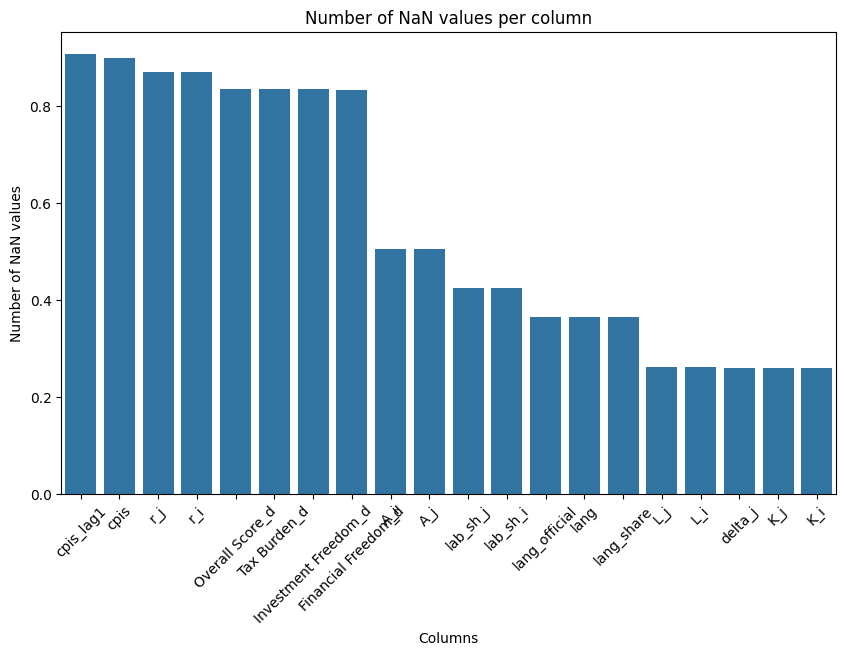

In [6]:
# Get nan counts per column and plot in bar chart
nan_counts = df.isna().sum().sort_values(ascending=False).div(len(df)).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=nan_counts.index, y=nan_counts.values)
plt.xticks(rotation=45)
plt.title("Number of NaN values per column")
plt.xlabel("Columns")
plt.ylabel("Number of NaN values")
plt.show()

In [ ]:
df["ln_dist"] = np.log(df["dist"])
df["ln_cpis"] = np.log(df["cpis"])
df["ln_cpis_lag1"] = np.log(df["cpis_lag1"])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476225 entries, 0 to 1476224
Data columns (total 36 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   iso3_i                1476225 non-null  object 
 1   iso3_j                1476225 non-null  object 
 2   year                  1476225 non-null  int64  
 3   dist                  1359650 non-null  float64
 4   border                1359650 non-null  float64
 5   legal_i               1352425 non-null  float64
 6   lang                  936050 non-null   float64
 7   lang_share            936050 non-null   float64
 8   lang_official         936050 non-null   float64
 9   Overall Score_d       242757 non-null   float64
 10  Investment Freedom_d  244701 non-null   float64
 11  Financial Freedom_d   244944 non-null   float64
 12  Tax Burden_d          242757 non-null   float64
 13  cpis                  149182 non-null   float64
 14  cpis_lag1             137684 non-n

In [8]:
# Check if there are duplicates by iso_i, iso_j, year
duplicates = df.duplicated(subset=["iso3_i", "iso3_j", "year"])
print(f"Number of duplicate rows by iso3_i, iso3_j, year: {duplicates.sum()}")

Number of duplicate rows by iso3_i, iso3_j, year: 0


## Prepare simulation

In [ ]:
# Add robust log features used by the friction equation
for src_col, ln_col in [("dist", "ln_dist"), ("cpis", "ln_cpis"), ("cpis_lag1", "ln_cpis_lag1")]:
    if src_col in df.columns:
        vals = pd.to_numeric(df[src_col], errors="coerce")
        df[ln_col] = np.where(vals > 0, np.log(vals), np.nan)

# Ensure key numerics are numeric
for c in [
    "Y_i", "K_i", "L_i", "A_i", "delta_i", "lab_sh_i",
    "Y_j", "K_j", "L_j", "A_j", "delta_j", "lab_sh_j",
    "r_i", "r_j", "cpis", "cpis_lag1",
    "dist", "border", "lang", "lang_share", "lang_official",
    "ln_dist", "ln_cpis", "ln_cpis_lag1",
    "pop_i", "pop_j",
 ]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [ ]:
# Population growth (used as optional controls later)
df = df.sort_values(by=["iso3_i", "iso3_j", "year"]).copy()
df["pop_growth_i"] = df.groupby("iso3_i")["pop_i"].pct_change()
df["pop_growth_j"] = df.groupby("iso3_j")["pop_j"].pct_change()

# Quick data quality sanity
print("Rows:", len(df))
print("Unique source countries:", df["iso3_i"].nunique())
print("Unique destination countries:", df["iso3_j"].nunique())

/var/folders/_x/74827dzs033cwdj2j4gch59r0000gn/T/ipykernel_16738/384997277.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["pop_growth_i"] = df.groupby("iso3_i")["pop_i"].pct_change()
/var/folders/_x/74827dzs033cwdj2j4gch59r0000gn/T/ipykernel_16738/384997277.py:4: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["pop_growth_j"] = df.groupby("iso3_j")["pop_j"].pct_change()


In [29]:
# Countries we model explicitly (all others are collapsed to ROW)
example_countries = ["SWE", "DEU", "ITA", "ESP", "FRA"]

# ================= TEMPORARY SETTING =================
# Friction is explicitly turned OFF for now.
# - All omega regression coefficients are set to 0
# - phi_0 is set to 0 (so sigma_tilde == sigma)
PHI_0_FOR_NOW = 0.0

fric_coefs_dict = {
    "ln_dist": 0.0,
    "ln_cpis_lag1": 0.0,
    "border": 0.0,
    "lang_official": 0.0,
}

In [ ]:
def market_clearing(W_vec, w_mat):
    """V_j = sum_i w_{i,j} * W_i."""
    return w_mat.T @ W_vec


def _safe_series_from_year(data_t, key_col, value_col, countries_order, fallback):
    s = data_t.groupby(key_col)[value_col].median() if value_col in data_t.columns else pd.Series(dtype=float)
    s = s.reindex(countries_order).astype(float)
    s = s.fillna(s.median() if s.notna().any() else np.nan)
    s = s.fillna(fallback)
    return s.to_numpy(dtype=float)


def _build_omega_matrix(data_t, countries_order, fric_coefs_dict):
    """Build Omega_{i,j} from bilateral regressors using exp(X beta), with domestic Omega=inf."""
    N = len(countries_order)
    cidx = {c: i for i, c in enumerate(countries_order)}
    omega = np.zeros((N, N), dtype=float)

    # Try info helper first if it supports this signature; else fallback below.
    info_fn = getattr(Information, "compute_omega", None)
    if callable(info_fn):
        try:
            out = info_fn(data_t.copy(), fric_coefs_dict)
            if isinstance(out, pd.Series) and len(out) == len(data_t):
                tmp = data_t[["iso3_i", "iso3_j"]].copy()
                tmp["omega"] = pd.to_numeric(out, errors="coerce")
                tmp = tmp.dropna(subset=["omega"]).drop_duplicates(["iso3_i", "iso3_j"], keep="last")
                for _, row in tmp.iterrows():
                    i = cidx.get(row["iso3_i"])
                    j = cidx.get(row["iso3_j"])
                    if i is None or j is None or i == j:
                        continue
                    omega[i, j] = max(float(row["omega"]), 0.0)
                np.fill_diagonal(omega, np.inf)
                return omega
        except Exception:
            pass

    pair_cols = ["iso3_i", "iso3_j"] + [c for c in fric_coefs_dict.keys() if c in data_t.columns]
    if len(pair_cols) > 2:
        pairs = data_t[pair_cols].drop_duplicates(["iso3_i", "iso3_j"], keep="last").copy()
    else:
        pairs = data_t[["iso3_i", "iso3_j"]].drop_duplicates(["iso3_i", "iso3_j"], keep="last").copy()

    for _, row in pairs.iterrows():
        i = cidx.get(row["iso3_i"])
        j = cidx.get(row["iso3_j"])
        if i is None or j is None or i == j:
            continue

        lin = 0.0
        for col, beta in fric_coefs_dict.items():
            if col in pairs.columns:
                x = row[col]
                if pd.isna(x):
                    x = 0.0
                lin += float(beta) * float(x)

        # keep in stable numeric range
        omega[i, j] = float(np.exp(np.clip(lin, -20, 20)))

    np.fill_diagonal(omega, np.inf)
    return omega


def inner_equilibrium(*,
                      K_vec,
                      K_vec_prev,
                      W_vec,
                      w_mat,
                      w_mat_prev,
                      omega_mat,
                      A0_vec,
                      L_vec,
                      s_vec,
                      sigma_vec,
                      rho,
                      phi_0,
                      alpha,
                      gamma,
                      delta,
                      alpha_v=0.88,
                      beta_v=0.88,
                      lam=2.25,
                      gamma_plus=0.61,
                      delta_minus=0.69,
                      max_iter=100,
                      tol=1e-6):
    """Inner fixed-point loop following utils/v3/simulation.py."""
    N = len(K_vec)
    K_vec = K_vec.copy()
    w_mat = w_mat.copy()

    pbar = tqdm(range(max_iter), desc="  inner-equilibrium", leave=False)
    for iteration in pbar:
        # 1) Market clearing
        V_vec = market_clearing(W_vec, w_mat)
        V_vec = np.maximum(V_vec, 1e-10)

        # 2) Implied required returns
        r_vec = np.array([
            Firm.implied_return(
                Firm.expected_dividend(A0_vec[j], K_vec[j], L_vec[j], s_vec[j], alpha, gamma),
                K_vec[j], K_vec_prev[j], V_vec[j]
            )
            for j in range(N)
        ], dtype=float)

        # 3) Reference points (same across households for asset j)
        r_0_vec = r_vec.copy()

        # 4) Perceived volatility with information frictions
        sigma_tilde_mat = np.array([
            [Household.sigma_tilde(sigma_vec[j], phi_0, omega_mat[i, j]) for j in range(N)]
            for i in range(N)
        ], dtype=float)

        # 5) CPT household portfolio updates
        w_new = np.zeros((N, N), dtype=float)
        for i in range(N):
            w_i, _ = Household.cpt_portfolio(
                r_implied_vec=r_vec,
                r_0_vec=r_0_vec,
                sigma_tilde_vec=sigma_tilde_mat[i],
                w_prev=w_mat_prev[i],
                rho=rho,
                alpha_v=alpha_v,
                beta_v=beta_v,
                lam=lam,
                gamma_plus=gamma_plus,
                delta_minus=delta_minus,
            )
            w_new[i] = w_i

        # 6) Firm capital adjustment
        K_new = np.array([
            Firm.equilibrium_capital(A0_vec[j], L_vec[j], alpha, gamma, r_vec[j], delta)
            for j in range(N)
        ], dtype=float)
        K_new = np.maximum(K_new, 1e-10)

        # 7) Convergence
        mpk_vec = np.array([Firm.mpk(A0_vec[j], K_new[j], L_vec[j], alpha, gamma) for j in range(N)], dtype=float)
        loss = np.sum((mpk_vec - (r_vec + delta)) ** 2)

        K_vec = K_new
        w_mat = w_new
        
        # Update tqdm description with loss
        pbar.set_description(f"  inner-equilibrium | loss: {loss:,.2f}")

        if loss < tol:
            break
    
    pbar.close()

    V_vec = market_clearing(W_vec, w_mat)
    V_vec = np.maximum(V_vec, 1e-10)
    Q_vec = V_vec / np.maximum(K_vec, 1e-10)
    return K_vec, w_mat, V_vec, r_vec, Q_vec, iteration + 1


def realise_period(*,
                  K_vec,
                  K_vec_prev,
                  V_vec,
                  w_mat,
                  W_vec,
                  A0_vec,
                  L_vec,
                  s_vec,
                  alpha,
                  gamma,
                  delta,
                  sigma_eps,
                  rng):
    """Realisation step following utils/v3/simulation.py."""
    N = len(K_vec)

    A_vec = np.array([Firm.realised_tfp(A0_vec[j], K_vec[j], gamma, sigma_eps, rng) for j in range(N)], dtype=float)
    Y_vec = np.array([Firm.output(A_vec[j], K_vec[j], L_vec[j], alpha) for j in range(N)], dtype=float)
    D_vec = np.array([Firm.dividend(Y_vec[j], s_vec[j], alpha) for j in range(N)], dtype=float)

    W_vec_new = np.array([
        Household.update_wealth(w_mat[i], D_vec, K_vec, K_vec_prev, V_vec, W_vec[i])
        for i in range(N)
    ], dtype=float)
    W_vec_new = np.maximum(W_vec_new, 1e-8)

    K_vec_new = np.array([
        Firm.capital_next_period(Y_vec[j], K_vec[j], s_vec[j], delta, alpha)
        for j in range(N)
    ], dtype=float)
    K_vec_new = np.maximum(K_vec_new, 1e-10)

    cpis_mat = np.array([Household.bilateral_positions(w_mat[i], W_vec_new[i]) for i in range(N)], dtype=float)
    return Y_vec, D_vec, W_vec_new, K_vec_new, cpis_mat


def run_simulation(*,
                   df,
                   fric_coefs_dict,
                   countries,
                   T,
                   start_year=None,
                   rho=0.50,
                   phi_0=0.20,
                   alpha=None,
                   gamma=0.05,
                   delta=None,
                   sigma_eps=0.03,
                   retention_rate=0.25,
                   seed=42,
                   max_inner_iter=100,
                   tol=1e-6,
                   disable_tqdm=False):
    """
    Full country simulation with ROW aggregation and CPT/firm equilibrium.

    - Non-target countries are collapsed to ROW via Countries.aggregate_row
    - Uses utils/v3 helper functions from Household + Firm
    - Omega is constructed from bilateral regressors using fric_coefs_dict
    """
    data = df.copy()
    data = data.sort_values(["year", "iso3_i", "iso3_j"]).copy()

    # === Collapse non-target countries into ROW ===
    row_countries = sorted(set(data["iso3_i"].dropna().unique()) - set(countries))
    data_row = Countries.aggregate_row(data, row_countries=row_countries, row_label="ROW")
    Countries.quick_asserts(data, data_row, row_countries=row_countries, row_label="ROW")

    years_all = sorted(data_row["year"].dropna().unique())
    if len(years_all) == 0:
        raise ValueError("No years available after ROW aggregation.")

    if start_year is None:
        start_year = years_all[0]
    years = [y for y in years_all if y >= start_year][:T]
    if len(years) == 0:
        raise ValueError("No simulation years available for the selected start_year/T.")

    # Country order from first simulated year, always include ROW
    data_t0 = data_row[data_row["year"] == years[0]].copy()
    countries_order = sorted(set(data_t0["iso3_i"]).union(set(data_t0["iso3_j"])))
    if "ROW" in countries_order:
        countries_order = [c for c in countries_order if c != "ROW"] + ["ROW"]
    N = len(countries_order)
    cidx = {c: i for i, c in enumerate(countries_order)}

    # === Parameter vectors from data (country-level) ===
    K_vec = _safe_series_from_year(data_t0, "iso3_i", "K_i", countries_order, fallback=1.0)
    L_vec = _safe_series_from_year(data_t0, "iso3_i", "L_i", countries_order, fallback=1.0)
    A0_vec = _safe_series_from_year(data_t0, "iso3_i", "A_i", countries_order, fallback=1.0)
    Y_vec0 = _safe_series_from_year(data_t0, "iso3_i", "Y_i", countries_order, fallback=1.0)

    # alpha from labour share if not provided
    if alpha is None:
        if "lab_sh_i" in data_row.columns and data_row["lab_sh_i"].notna().any():
            alpha = float(1 - data_row["lab_sh_i"].median())
        else:
            alpha = 0.33
    alpha = float(np.clip(alpha, 0.10, 0.85))
    gamma = float(min(gamma, alpha - 1e-4))

    if delta is None:
        if "delta_i" in data_row.columns and data_row["delta_i"].notna().any():
            delta = float(data_row["delta_i"].median())
        else:
            delta = 0.06
    delta = float(np.clip(delta, 0.001, 0.30))

    s_vec = np.full(N, float(np.clip(retention_rate, 0.0, 0.95)), dtype=float)

    if "r_j" in data_row.columns:
        sigma_s = data_row.groupby("iso3_j")["r_j"].std().reindex(countries_order)
        sigma_med = float(np.nanmedian(sigma_s.to_numpy(dtype=float))) if sigma_s.notna().any() else 0.15
        sigma_vec = sigma_s.fillna(sigma_med if np.isfinite(sigma_med) else 0.15).to_numpy(dtype=float)
    else:
        sigma_vec = np.full(N, 0.15, dtype=float)
    sigma_vec = np.clip(sigma_vec, 1e-4, None)

    # === Initial bilateral positions and portfolio weights ===
    cpis_col = "cpis_lag1" if "cpis_lag1" in data_t0.columns else "cpis"
    cpis_mat0 = np.zeros((N, N), dtype=float)
    for _, row in data_t0[["iso3_i", "iso3_j", cpis_col]].dropna(subset=["iso3_i", "iso3_j"]).iterrows():
        i = cidx.get(row["iso3_i"])
        j = cidx.get(row["iso3_j"])
        if i is None or j is None or i == j:
            continue
        val = 0.0 if pd.isna(row.get(cpis_col, np.nan)) else float(row[cpis_col])
        if np.isfinite(val) and val > 0:
            cpis_mat0[i, j] += val

    row_sums = cpis_mat0.sum(axis=1, keepdims=True)
    w_mat = np.divide(cpis_mat0, np.where(row_sums == 0, 1.0, row_sums))

    # If a row has no historical positions, use diversified baseline
    zero_rows = np.where(row_sums.ravel() == 0)[0]
    for i in zero_rows:
        w_mat[i, :] = 1.0 / N

    # Initial household wealth (from observed positions if possible)
    W_vec = cpis_mat0.sum(axis=1)
    if not np.isfinite(W_vec).all() or np.all(W_vec <= 0):
        pe_ratio = 12.0
        base_size = float(np.nanmean(Y_vec0)) if np.isfinite(np.nanmean(Y_vec0)) else float(np.nanmean(K_vec))
        if not np.isfinite(base_size) or base_size <= 0:
            base_size = 1.0
        W_vec = np.full(N, pe_ratio * base_size, dtype=float)
    W_vec = np.maximum(W_vec, 1e-8)

    # Keep previous-period objects
    K_prev = K_vec.copy()
    w_mat_prev = w_mat.copy()

    # Build Omega panel for all simulated years
    omega_panel = {
        year: _build_omega_matrix(data_row[data_row["year"] == year], countries_order, fric_coefs_dict)
        for year in years
    }

    rng = np.random.default_rng(seed)
    history = []

    for year in tqdm(years, desc="Simulating", disable=disable_tqdm):
        omega_mat = omega_panel[year]

        K_eq, w_eq, V_vec, r_vec, Q_vec, n_iter = inner_equilibrium(
            K_vec=K_vec,
            K_vec_prev=K_prev,
            W_vec=W_vec,
            w_mat=w_mat,
            w_mat_prev=w_mat_prev,
            omega_mat=omega_mat,
            A0_vec=A0_vec,
            L_vec=L_vec,
            s_vec=s_vec,
            sigma_vec=sigma_vec,
            rho=rho,
            phi_0=phi_0,
            alpha=alpha,
            gamma=gamma,
            delta=delta,
            max_iter=max_inner_iter,
            tol=tol,
        )

        Y_vec, D_vec, W_new, K_new, cpis_mat = realise_period(
            K_vec=K_eq,
            K_vec_prev=K_prev,
            V_vec=V_vec,
            w_mat=w_eq,
            W_vec=W_vec,
            A0_vec=A0_vec,
            L_vec=L_vec,
            s_vec=s_vec,
            alpha=alpha,
            gamma=gamma,
            delta=delta,
            sigma_eps=sigma_eps,
            rng=rng,
        )

        history.append({
            "year": year,
            "countries": countries_order,
            "K_vec": K_new.copy(),
            "W_vec": W_new.copy(),
            "w_mat": w_eq.copy(),
            "cpis_mat": cpis_mat.copy(),
            "Y_vec": Y_vec.copy(),
            "D_vec": D_vec.copy(),
            "V_vec": V_vec.copy(),
            "r_vec": r_vec.copy(),
            "Q_vec": Q_vec.copy(),
            "n_iter": int(n_iter),
        })

        # Roll state
        K_prev = K_eq.copy()
        K_vec = K_new.copy()
        W_vec = W_new.copy()
        w_mat_prev = w_eq.copy()
        w_mat = w_eq.copy()

    # Make tidy output for inspection
    recs = []
    for h in history:
        for j, c in enumerate(h["countries"]):
            recs.append({
                "year": h["year"],
                "iso3": c,
                "K": h["K_vec"][j],
                "W": h["W_vec"][j],
                "Y": h["Y_vec"][j],
                "D": h["D_vec"][j],
                "V": h["V_vec"][j],
                "r": h["r_vec"][j],
                "Q": h["Q_vec"][j],
                "n_iter": h["n_iter"],
            })
    history_long = pd.DataFrame(recs).sort_values(["year", "iso3"]).reset_index(drop=True)

    return {
        "history": history,
        "history_long": history_long,
        "countries": countries_order,
        "row_countries": row_countries,
        "aggregated_data": data_row,
        "params": {
            "alpha": alpha,
            "gamma": gamma,
            "delta": delta,
            "rho": rho,
            "phi_0": phi_0,
            "sigma_eps": sigma_eps,
            "retention_rate": retention_rate,
        },
    }


# ============= EXAMPLE SIMULATION (quick smoke test) =============
sim_result = run_simulation(
    df=df,
    fric_coefs_dict=fric_coefs_dict,
    countries=example_countries,
    T=2,
    start_year=None,
    seed=42,
    disable_tqdm=False,
    max_inner_iter=10,
    tol=1e-5,
 )

sim_result["history_long"].head(20)

Simulating: 100%|██████████| 2/2 [00:13<00:00,  6.59s/it]


,year,iso3,K,W,Y,D,V,r,Q,n_iter
0,1997,DEU,737.826268,8.322085e+07,81.938427,24.020068,6.795581e+07,5.026614e-06,89727.047980,1
1,1997,ESP,418.442363,8.322085e+07,44.148655,12.942080,6.795581e+07,2.750598e-06,158126.239258,1
2,1997,FRA,560.033376,8.322085e+07,63.209002,18.529579,6.795581e+07,4.116826e-06,118233.721258,1
3,1997,ITA,675.700856,8.322085e+07,76.382370,22.391323,6.795581e+07,4.679004e-06,97995.992886,1
4,1997,ROW,30850.906179,8.322085e+07,3140.840216,920.730360,4.756906e+08,1.590196e-04,15007.594073,1
5,1997,SWE,85.481773,8.322085e+07,8.577379,2.514440,6.795581e+07,6.256132e-07,773650.174388,1
6,1998,DEU,737.913067,8.322108e+07,81.289943,23.829967,2.080521e+07,9.479416e-08,27465.001794,1
7,1998,ESP,418.605102,8.322108e+07,45.336269,13.290227,2.080521e+07,4.819987e-08,48406.154570,1
8,1998,FRA,559.938999,8.322108e+07,61.287252,17.966222,2.080521e+07,7.436439e-08,36192.094928,1
9,1998,ITA,675.383792,8.322108e+07,71.828347,21.056321,2.080521e+07,9.001396e-08,29996.513546,1


- Next step: calibrate `fric_coefs_dict` by minimizing loss against observed moments.

## ROW

In [31]:
# Re-run with friction OFF (temporary assumption)
sim_result = run_simulation(
    df=df,
    fric_coefs_dict=fric_coefs_dict,
    countries=example_countries,
    T=10,
    start_year=None,
    phi_0=PHI_0_FOR_NOW,  # <-- friction set to zero for now
    seed=42,
    disable_tqdm=False,
    max_inner_iter=100,
    tol=1e-5,
 )

print("TEMP ASSUMPTION: Friction is OFF (phi_0 = 0.0, omega-coefs = 0.0)")
print("Model countries:", sim_result["countries"])
print("Number of countries collapsed to ROW:", len(sim_result["row_countries"]))
print("Sample of collapsed countries:", sim_result["row_countries"][:10])

# Final-year country diagnostics
final_year = sim_result["history_long"]["year"].max()
sim_result["history_long"].query("year == @final_year").sort_values("Q", ascending=False)

Simulating: 100%|██████████| 10/10 [01:16<00:00,  7.69s/it]

TEMP ASSUMPTION: Friction is OFF (phi_0 = 0.0, omega-coefs = 0.0)
Model countries: ['DEU', 'ESP', 'FRA', 'ITA', 'SWE', 'ROW']
Number of countries collapsed to ROW: 238
Sample of collapsed countries: ['ABW', 'AFG', 'AGO', 'AIA', 'ALB', 'AND', 'ANT', 'ARE', 'ARG', 'ARM']


,year,iso3,K,W,Y,D,V,r,Q,n_iter
58,2006,ROW,31097.705736,8.322253e+07,3594.566587,1053.739242,4.989277e+08,3.111206e-07,15637.049591,1
59,2006,SWE,85.518733,8.322253e+07,9.018739,2.643823,8.127182e+04,2.372407e-06,925.315159,1
55,2006,ESP,418.321119,8.322253e+07,44.799088,13.132754,8.127182e+04,1.345174e-05,189.195668,1
56,2006,FRA,559.452034,8.322253e+07,60.623226,17.771564,8.127182e+04,1.834962e-05,141.485703,1
57,2006,ITA,675.337628,8.322253e+07,77.771444,22.798527,8.127182e+04,2.259035e-05,117.285986,1
54,2006,DEU,736.932240,8.322253e+07,79.049187,23.173094,8.127182e+04,2.513386e-05,107.399174,1
